# Predicción del precio de autos usados

* **Problema:** estimar el precio de venta de un auto usado a partir de sus características (marca, modelo, año, kilometraje, ciudad, etc.).

* **Tipo de problema:** regresión supervisada.

* **Variable objetivo:** `sale_price` (precio de venta, en rupias indias).

* **Objetivo del modelo:** predecir el precio de un auto que no está en los datos de entrenamiento.

* **Fuente de los datos:** Used Car Price Prediction (Kaggle, vrajesh0sharma7). [link.](https://www.kaggle.com/datasets/vrajesh0sharma7/used-car-price-prediction?resource=download)

In [1]:
# Importación de librerías
import numpy as np            # Operaciones matemáticas y manejo de arrays numéricos
import pandas as pd           # Manipulación, limpieza y análisis de estructuras de datos (DataFrames)
import matplotlib.pyplot as plt # Creación y personalización de gráficos y visualizaciones
import seaborn as sns         # Visualización de datos estadísticos basada en Matplotlib


SEED = 42
np.random.seed(SEED)


pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/Used_Car_Price_Prediction.csv")
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,assured_buy,registered_city,registered_state,is_hot,rto,source,make,model,car_availability,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,True,delhi,delhi,True,dl6c,inperson_sale,maruti,swift,in_stock,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,True,noida,uttar pradesh,True,up16,inperson_sale,maruti,alto 800,in_stock,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,True,agra,uttar pradesh,True,up80,inperson_sale,hyundai,grand i10,in_stock,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,True,delhi,delhi,True,dl1c,inperson_sale,maruti,swift,in_stock,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,False,new delhi,delhi,True,dl12,inperson_sale,hyundai,grand i10,in_stock,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [3]:
print(df.shape)
df.dtypes.value_counts()

(7400, 29)


str        15
int64       8
bool        4
float64     1
object      1
Name: count, dtype: int64

## Descripción del conjunto de datos

- **Observaciones:** 7.400 anuncios de autos usados.

- **Variables:** 29 en total, es decir, 28 predictoras y la variable objetiva.

- **Variable objetivo:** `sale_price`, el precio de venta del auto usado en rupias indias.

- **Tipos de variables:**
  - 9 numéricas (8 enteras y 1 decimal), incluida la variable objetiva.
  - 5 booleanas (4 `bool` y `fitness_certificate`, que Python guarda como `object` porque tiene nulos).
  - 14 categóricas de texto (marca, modelo, ciudad, tipo de combustible, etc.).
  - 1 fecha de publicación del anuncio (`ad_created_on`).

- **Limitaciones:**
  - Son autos de India, de una sola plataforma de venta, por lo que el modelo no generaliza a otros mercados.
  - Los anuncios cubren un periodo corto (de febrero de 2019 a mayo de 2021).
  - Incluye columnas derivadas del precio (cuotas, pago inicial, cotizaciones), que se tratarán como posible fuga de información.
  - Hay valores faltantes en varias columnas y algunos registros con precio 0 o duplicados.

# Exploración (EDA)

In [4]:
#Estadísticas descriptivas
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   str    
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   str    
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   str    
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   str    
 8   transmission         6844 non-null   str    
 9   variant              7400 non-null   str    
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   str    
 12  registered_state     7390 non-null   str    
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   str    
 15  source               7274 non-null   str    
 16 

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,emi_starts_from,booking_down_pymnt
count,7400.000000,7400.000000,7.400000e+03,7400.000000,7400.000000,7.400000e+03,4.120000e+03,7400.000000,7400.000000
mean,2013.885676,62624.520000,4.548892e+05,1550.706081,1.327297,4.322044e+05,5.510351e+05,10565.942027,68233.529054
std,3.087613,43532.042371,2.827023e+05,2080.952842,0.579798,2.880316e+05,3.119887e+05,6566.468434,42405.389468
min,1996.000000,60.000000,0.000000e+00,3.000000,1.000000,0.000000e+00,9.689900e+04,0.000000,0.000000
25%,2012.000000,31885.250000,2.811740e+05,554.750000,1.000000,2.526612e+05,3.414930e+05,6531.250000,42176.250000
50%,2014.000000,55765.000000,3.824490e+05,1088.000000,1.000000,3.611445e+05,4.674800e+05,8883.000000,57367.500000
75%,2016.000000,84184.000000,5.401490e+05,1926.500000,2.000000,5.260180e+05,6.675258e+05,12546.250000,81022.500000
max,2021.000000,996609.000000,3.866000e+06,61930.000000,6.000000,3.250000e+06,2.765057e+06,89798.000000,579901.000000


`df.info()` confirma que solo 9 de las 29 columnas son numéricas (`int64`); el resto son `str` (texto/categóricas) o `bool`. Se ve claramente el hueco de `transmission` (6.844 de 7.400, es decir, faltan 556) y `body_type` (7.297, faltan 103), que ya habíamos identificado en la tabla de nulos.

En `describe()`: el año de fabricación va de 1996 a 2021, con mediana en 2014. `kms_run` tiene mediana de 55.765 km pero un máximo de 996.609 km, un valor atípico extremo a revisar más adelante. `total_owners` va de 1 a 6 dueños, con la mayoría en 1-2.

In [5]:
#Nulos por columna
nulos = df.isna().sum()
pct = (df.isna().mean()*100).round(2)
pd.DataFrame({"nulos": nulos, "%": pct}).query("nulos > 0").sort_values("%", ascending=False)


,nulos,%
original_price,3280,44.32
car_availability,620,8.38
transmission,556,7.51
source,126,1.70
body_type,103,1.39
registered_state,10,0.14
registered_city,10,0.14
car_rating,9,0.12
fitness_certificate,8,0.11
ad_created_on,1,0.01


Hay valores faltantes en 10 de las 29 columnas. `original_price` (44,32 %) y `car_availability` (8,38 %) tienen demasiados nulos para imputarlos con confianza; se eliminarán en el tratamiento de fuga de información. `transmission` (7,51 %) también supera el rango esperado.

Dentro del rango que exige el proyecto (0,1 %–2 %) están: `source` (1,70 %), `body_type` (1,39 %), `registered_state` y `registered_city` (0,14 % cada una), `car_rating` (0,12 %) y `fitness_certificate` (0,11 %). Estas se tratarán en la etapa de preparación de datos.

`ad_created_on` tiene solo 1 nulo (0,01 %); esa fila se puede eliminar directamente.

In [6]:
#Impacto de nulos en transmission
df.groupby(df.transmission.isna())["sale_price"].mean()

transmission
False    435463.191701
True     694010.678058
Name: sale_price, dtype: float64

El precio medio de los autos con `transmission` nula es 694.011 rupias, muy por encima de los 435.463 de los que sí tienen el dato (60 % más alto). Esto indica que el nulo **no es aleatorio**: probablemente los autos más caros o de gama alta (donde `transmission` es menos frecuente reportar, o corresponde a modelos particulares) concentran más faltantes.

Por eso, imputar `transmission` con la moda (`manual`, la más común) sesgaría hacia abajo justo los autos de mayor valor. Se evaluará una imputación diferenciada o una categoría `"desconocido"` en vez de la moda simple, para no introducir ese sesgo.

Text(0.5, 1.0, 'Precio (log)')

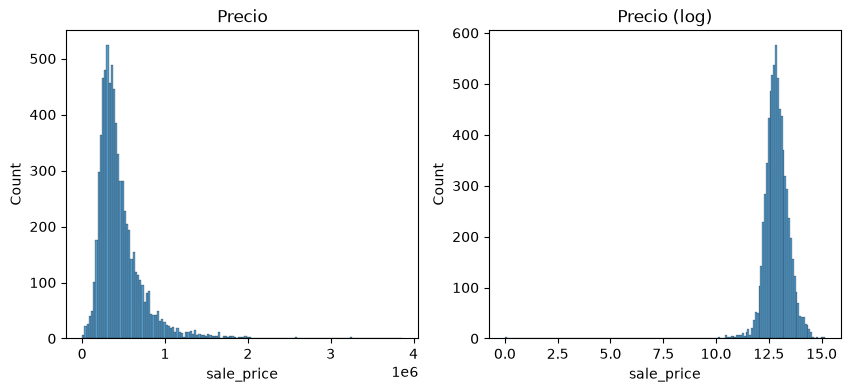

In [7]:
#Distribución de sale_price
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(df.sale_price, ax=ax[0]); ax[0].set_title("Precio")
sns.histplot(np.log1p(df.sale_price), ax=ax[1]); ax[1].set_title("Precio (log)")

`sale_price` tiene una distribución muy sesgada a la derecha: la mayoría de los autos cuestan menos de 1 millón de rupias, pero hay una cola de precios altos que llega hasta ~4 millones. Al aplicar log1p, la distribución se vuelve mucho más simétrica y cercana a una normal.

Por esto se entrenará el modelo prediciendo `log(sale_price)` en lugar del precio directo, y se revertirá la transformación (`expm1`) al momento de evaluar y generar predicciones.

In [14]:
#Correlación de numéricas con el objetivo
df.select_dtypes("number").corr()["sale_price"].sort_values(ascending=False)

sale_price            1.000000
booking_down_pymnt    1.000000
emi_starts_from       1.000000
original_price        0.986005
broker_quote          0.963484
yr_mfr                0.518973
times_viewed          0.091579
kms_run              -0.104727
total_owners         -0.131306
Name: sale_price, dtype: float64

`booking_down_pymnt` y `emi_starts_from` tienen correlación 1,0 con `sale_price`: son cuotas y pagos calculados directamente a partir del precio, así que se eliminarán por fuga de información directa.

`original_price` (0,986) y `broker_quote` (0,963) también están casi perfectamente correlacionadas con el precio. Además, `original_price` tiene 44,32 % de nulos. Ambas se eliminarán por el mismo motivo.

Del resto, `yr_mfr` (0,52) es la variable con relación más fuerte y legítima con el precio: a mayor año de fabricación, mayor precio. `kms_run` y `total_owners` tienen correlación negativa débil, como se esperaría (más kilometraje o más dueños, menor precio). `times_viewed` (0,09) es prácticamente irrelevante y además no estaría disponible al momento de predecir un auto nuevo, por lo que también se eliminará.

In [9]:
#duplicados y precios en 0
print("Duplicados:", df.duplicated().sum())
print("Precio en 0:", (df.sale_price == 0).sum())

Duplicados: 1
Precio en 0: 3


Hay 1 fila duplicada exacta y 3 registros con `sale_price` = 0, lo cual no tiene sentido para un auto en venta. Ambos casos se eliminarán antes del entrenamiento del modelo, en la etapa de preparación de datos.

([0, 1], [Text(0, 0, 'manual'), Text(1, 0, 'automatic')])

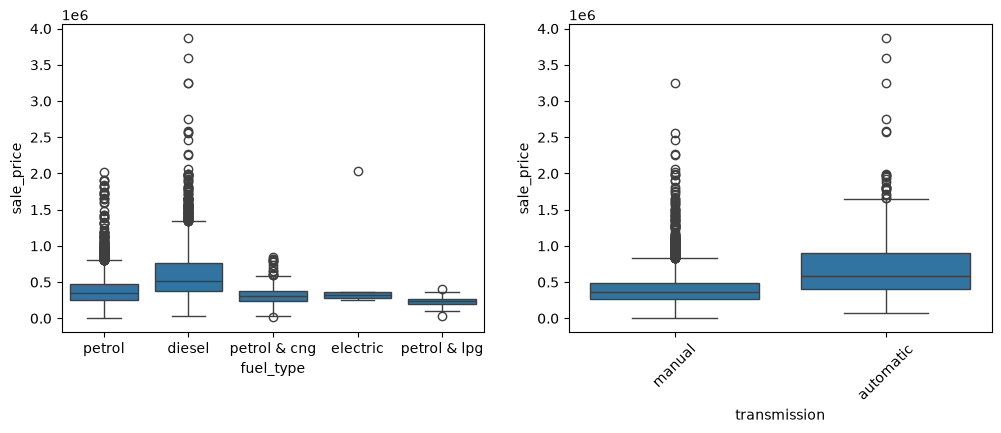

In [10]:
#Precio vs. fuel_type
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x="fuel_type", y="sale_price", ax=ax[0])
sns.boxplot(data=df, x="transmission", y="sale_price", ax=ax[1])
plt.xticks(rotation=45)

Por combustible, `diesel` tiene la mediana de precio más alta, seguido de `petrol`; `electric`, `petrol & cng` y `petrol & lpg` son categorías con muy pocos autos y precios más bajos y concentrados.

Por transmisión, los autos `automatic` tienen una mediana claramente más alta que los `manual`, lo cual es consistente con el mercado: los automáticos suelen ser versiones más equipadas y costosas.

En ambos casos se ven varios valores atípicos hacia precios altos, coherente con el sesgo ya observado en `sale_price`.

In [11]:
#Precio vs. make
df.groupby("make")["sale_price"].median().sort_values(ascending=False)

make
jaguar              3866000.0
mg                  1705686.0
kia                 1567518.0
jeep                1389758.0
mercedes benz       1308049.0
audi                1202706.0
bmw                 1145742.0
volvo               1142399.0
isuzu                884551.5
mahindra             700000.0
ssangyong            595799.0
toyota               540000.0
volkswagen           438799.0
ford                 435899.0
skoda                405299.0
honda                391999.0
nissan               376899.0
hyundai              368449.0
maruti               364299.0
renault              354549.0
tata                 346499.0
mitsubishi           307099.0
fiat                 292399.0
datsun               259499.0
chevrolet            190549.0
mahindra renault     102000.0
opel                  24000.0
Name: sale_price, dtype: float64

`make` tiene 27 categorías con una jerarquía de precio muy marcada: las marcas premium encabezan la lista (`jaguar` con mediana de 3.866.000, `mg`, `kia`, `jeep`, `mercedes benz`, `audi`, `bmw`, `volvo`, todas por encima de 1 millón de rupias), mientras que las marcas populares/económicas (Maruti, Hyundai, Tata, etc., las más frecuentes en el dataset según el head visto antes) se ubican bastante más abajo.

Esto confirma que `make` es una variable predictora fuerte y necesaria; con 27 categorías, se codificará con one-hot encoding sin problema de dimensionalidad excesiva.

<Axes: xlabel='kms_run', ylabel='sale_price'>

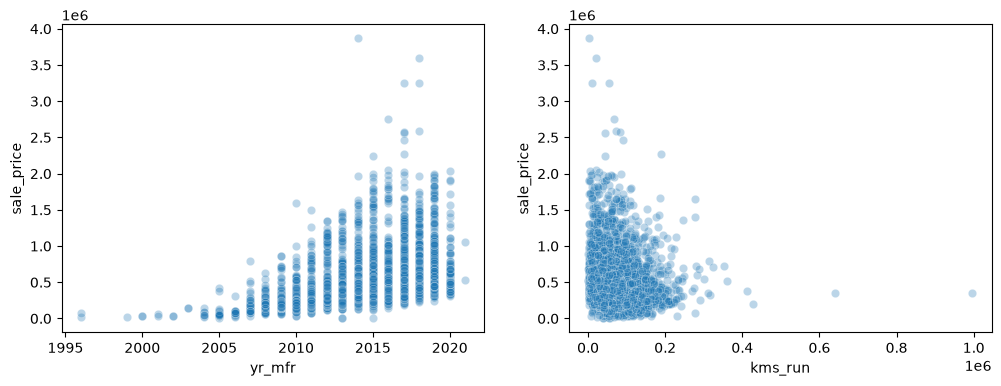

In [12]:
#Precio vs. yr_mfr y kms_run
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(data=df, x="yr_mfr", y="sale_price", ax=ax[0], alpha=0.3)
sns.scatterplot(data=df, x="kms_run", y="sale_price", ax=ax[1], alpha=0.3)

Como se esperaba por la correlación, `yr_mfr` muestra una relación positiva clara: los autos más recientes (2015-2021) alcanzan precios mucho más altos y dispersos, mientras que los anteriores a 2005 se concentran en precios bajos.

`kms_run` muestra la relación inversa: la mayoría de los precios altos se concentra en autos con menos de 200.000 km, y hay muy pocos casos con kilometrajes extremos (por encima de 400.000 km), que además tienden a precios bajos.

<Axes: >

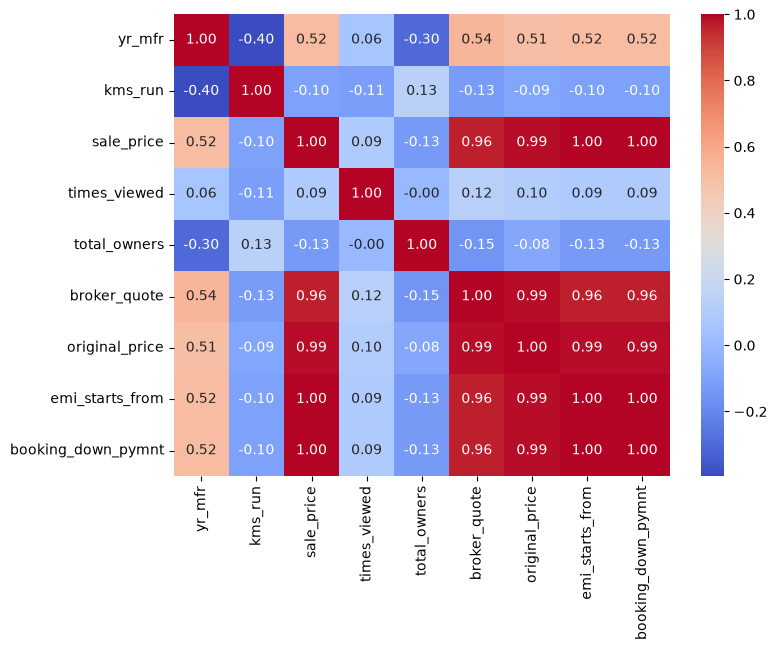

In [13]:
#Correlación entre todas las numéricas
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")

El mapa de calor confirma que `broker_quote`, `original_price`, `emi_starts_from` y `booking_down_pymnt` están correlacionadas entre sí (0,96–1,00), además de con `sale_price`. Son esencialmente la misma información repetida (variantes del precio), así que basta con eliminarlas todas y quedarse con el precio real.

Entre las variables que sí se van a conservar, no hay correlaciones altas entre sí: `yr_mfr`, `kms_run`, `times_viewed` y `total_owners` están todas por debajo de 0,4 en valor absoluto, así que no hay redundancia que resolver ahí.